# PLOG

In [1]:
# --------------------------------------------------------
# Import packages
# --------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from diffPLOG2TROE.kinetic_constants import Plog

## Pressure Logarithmic Reaction
Introduced by J. Miller, as a generalized polynomial fitting for temperature and pressure dependent kinetic constants, by defining the following expression for the kinetic constant:
- Equation
  > $k_f \left(T, P_{i}\right) = \sum_{k=1}^{M} A_{i, k} \: T^{n_{i, k}} \: exp\left(-E_{act}^{i,k}/(RT)\right), \quad i=1, ..., Np, \quad M \geq 1$
  
  at a set of pressures, $P = P_{1}, P_{2}, ..., P_{Np}$. $M$ and $Np$ are user specified numbers. The extrapolation is bounded by the two pressure limits, $P_{1}$ and $P_{Np}$. To calculate $k \left(T, P_{i}\right)$ for any pressure, interpolate $logk$ as a linear function of $logP$. If $P$ is between $P_{i}$ and $P_{i+1}$ for any temperature a rate constant can be find from:
  > $logk \left(T, P\right) = logk\left(T, P_{i}\right) + \left(logP - logP_{i}\right) \frac{logk\left(T, P_{i+1}\right) - logk\left(T, P_{i}\right)}{logP_{i+1} - logP_{i}}$
- CHEMKIN representation
  >```
  >  NH3=NH2+H   .3497E+31  -5.224  111163.3
  >  PLOG / 0.1  .7230E+30  -5.316  110862.4 /
  >  PLOG / 1    .3497E+31  -5.224  111163.3 /
  >  PLOG / 10   .1975E+32  -5.155  111887.8 /
  >  PLOG / 100  .2689E+32  -4.920  112778.7 /
  >```
- Internal representation
    >```python
    >plog_constant = {
    >    "name": "NH3=NH2+H",
    >    "type": "plog",
    >    "rate-constant": {
    >        "coefficients": [
    >            [0.1, .7230E+30, -5.316, 110862.4],
    >            [1, .3497E+31, -5.224, 111163.3],
    >            [10, .1975E+32, -5.155, 111887.8],
    >            [100, .2689E+32, -4.920, 112778.7],
    >        ]
    >    }
    >}
    >```

In [2]:
# --------------------------------------------------------
# Dictionary initialization
# --------------------------------------------------------
plog_constant = {
    "name": "NH3=NH2+H",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [0.1, .7230E+30, -5.316, 110862.4],
            [1, .3497E+31, -5.224, 111163.3],
            [10, .1975E+32, -5.155, 111887.8],
            [100, .2689E+32, -4.920, 112778.7],
        ]
    }
}
rate_constant = Plog(plog_constant)

# --------------------------------------------------------
# Direct parameters initialization
# --------------------------------------------------------
rate_constant = Plog(
    params=[
        [0.1, .7230E+30, -5.316, 110862.4],
        [1, .3497E+31, -5.224, 111163.3],
        [10, .1975E+32, -5.155, 111887.8],
        [100, .2689E+32, -4.920, 112778.7]
    ]
)

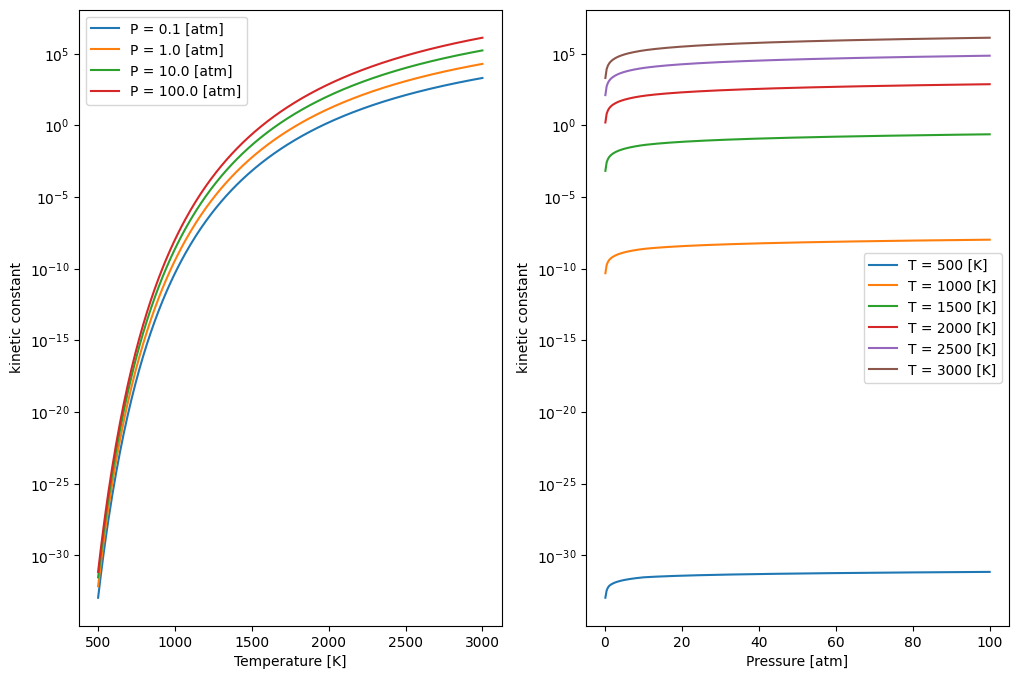

In [3]:
T_range = jnp.linspace(500, 3000, 300)
P_range = jnp.array([0.1, 1, 10, 100])
k_plog = rate_constant.kinetic_constant(T_range, P_range)

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
for i, j in enumerate(k_plog):
    plt.semilogy(T_range, j, label=f"P = {P_range[i]} [atm]")
plt.xlabel("Temperature [K]")
plt.ylabel("kinetic constant")
plt.legend()

T_range = jnp.array([500, 1000, 1500, 2000, 2500, 3000])
P_range = jnp.linspace(0.1, 100, 300)
k_plog = rate_constant.kinetic_constant(T_range, P_range)

plt.subplot(1, 2, 2)
for i in range(k_plog.shape[1]):
    plt.semilogy(P_range, k_plog[:, i], label=f"T = {T_range[i]} [K]")
plt.xlabel("Pressure [atm]")
plt.ylabel("kinetic constant")
plt.legend()
plt.show()